## 0. GPU Verification

It is mandatory to verify that a GPU is available, as Foundation Models (Chronos, TimesFM) require it for efficient execution. If no GPU is detected, these models will be excluded from the benchmark.

In [ ]:
import torch
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. Foundation models will run on CPU (very slow) or be skipped.")

# Evaluating Zero-Shot Foundation Models for Epidemiological Forecasting of Influenza-Like Illness in Italy

This notebook is designed to be a fully automated, "plug-and-play" environment to reproduce the benchmarking results of my thesis. It handles the environment setup, data ingestion from the official Influcast repository, and the execution of the zero-shot foundation models.

### Recommendation for Google Colab

Before starting, please ensure you are using a GPU Runtime:

1. Go to Runtime -> Change runtime type.
2. Select T4 GPU (or better).

## 1. Environment setup

As a first step we clone the github repo containg our codebase, and install the dependencies

In [1]:
%cd /content

# 1. clone the repo
REPO_URL = f"https://github.com/biagio-incardona/Biagio-Incardona-Master-thesis.git"
!git clone {REPO_URL}

/content
Cloning into 'Biagio-Incardona-Master-thesis'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 193 (delta 23), reused 184 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (193/193), 110.13 KiB | 7.87 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [2]:

# 2. install dependencies
%cd Biagio-Incardona-Master-thesis
!grep -vE "timesfm|tirex" requirements.txt > requirements_core.txt
!pip install -r requirements_core.txt

# 3. Install the foundation models directly from GitHub (force upgrade)
!pip install -U "timesfm[torch] @ git+https://github.com/google-research/timesfm.git"
!pip install git+https://github.com/NX-AI/tirex.git


# 3. Setup Python Path to recognize our 'src' directory

import sys
import os
from google.colab import userdata

sys.path.append(os.getcwd())
os.environ["TIMEGPT_TOKEN"] = userdata.get('TimeGPT')

/content/Biagio-Incardona-Master-thesis
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 35.0 MB/s eta 0:00:00
  

## 2. Data Ingestion & Preprocessing

We ingest raw **ILI** (Influenza-Like Illness) data from the `Influcast` repository and historical records. It is important to distinguish this from **ARI** (Acute Respiratory Infections), which has been introduced in more recent surveillance protocols (2024/25+) but is not the primary focus of this historical evaluation.

The preprocessing pipeline ensures:
   * **Epidemic Indexing**: To handle the seasonal nature of surveillance, we use an *epidemic time index* that concatenates observed weeks. This avoids artificial zero-filling during off-season periods.
   * **Metadata Preservation**: The actual calendar dates are preserved in a `calendar_ds` column to ensure proper mapping during visualization.
   * **Standardization**: All records are mapped to ISO weeks and Sunday-based dates.

  Columns:
   * **ds**: Synthetic date (weekly frequency) used for modeling.
   * **calendar_ds**: Real calendar Sunday of the observation.
   * **region**: Lowercase location name.
   * **y**: ILI incidence per 1,000 inhabitants.

In [3]:
print("Ingesting raw ILI data from Influcast...")
!python3 src/data/ingestion.py

print("\nPreprocessing data into standardized format (Epidemic Indexing)...")
!python3 src/data/preprocessing.py --time-index epidemic

# --- PROFESSOR GUIDELINE: SOURCE TRACKING ---
if os.path.exists('data/processed/source_files_index.csv'):
    print("\n--- SOURCE AUDIT MANIFEST (First 10 entries) ---")
    import pandas as pd
    manifest = pd.read_csv('data/processed/source_files_index.csv')
    from IPython.display import display
    display(manifest.head(10))

# --- PROFESSOR GUIDELINE: FULL REGIONAL INGESTION ---
if os.path.exists('data/processed/ili_gold.csv'):
    df = pd.read_csv('data/processed/ili_gold.csv')
    regions = df['region'].unique().tolist()
    print(f"\n✅ DATA READINESS VERIFIED")
    print(f"Total Regions Discovered: {len(regions)}")
    print(f"Total Observation Weeks: {len(df)}")
    print(f"Last date in series: {df['ds'].max()}")
    if len(regions) >= 22:
        print("⭐ Full panel of 22 geographic entities successfully ingested.")
else:
    print("\n❌ ERROR: Data preparation failed. Please check the ingestion logs.")

Ingesting raw ILI data from Influcast...
2026-06-16 13:38:34,772 - INFO - Cloning repository https://github.com/Predizioni-Epidemiologiche-Italia/Influcast.git into data/influcast_repo...
Cloning into 'data/influcast_repo'...
remote: Enumerating objects: 8938, done.
remote: Counting objects: 100% (8938/8938), done.
remote: Compressing objects: 100% (7948/7948), done.
remote: Total 8938 (delta 1009), reused 8833 (delta 971), pack-reused 0 (from 0)
Receiving objects: 100% (8938/8938), 10.88 MiB | 18.00 MiB/s, done.
Resolving deltas: 100% (1009/1009), done.
2026-06-16 13:38:37,743 - INFO - Copied italia-2004_17-ILI.csv for season 2003-2004
2026-06-16 13:38:37,743 - WARNING - No ILI data found for Lombardia in season 2003-2004
2026-06-16 13:38:37,743 - WARNING - No ILI data found for Lazio in season 2003-2004
2026-06-16 13:38:37,747 - WARNING - No ILI data found for Sicilia in season 2003-2004
2026-06-16 13:38:37,747 - WARNING - No ILI data found for Veneto in season 2003-2004
2026-06-16 1

## Step 3: Running the Full Benchmarking Suite

Now we run the full models suite. To make this a fair academic comparison, we evaluate both **Classical Baselines**, **Advanced ML**, and the latest **Foundation Models**.

We are testing for the following models:

* **Simple Baselines**: Naive, SeasonalNaive, Drift, MovingAverage
* **Statistical**: ETS, ARIMA, SARIMA, Prophet
* **Machine Learning**: LightGBM, XGBoost, CatBoost, Ridge
* **Foundation Models**: Chronos, TimesFM, TiRex, TimeGPT

To avoid memory issues in Colab, the benchmarking is split into stages. We use dynamic origin generation (rolling window backtest) with a standard step size.

Let's start with Statistical Baselines


In [4]:
print(">>> 1. Running Classical Baselines (SARIMA, ARIMA, Prophet, etc.)...")
!python3 benchmark_ili_national.py --model Naive
!python3 benchmark_ili_national.py --model SeasonalNaive --append
!python3 benchmark_ili_national.py --model Drift --append
!python3 benchmark_ili_national.py --model MovingAverage --append
!python3 benchmark_ili_national.py --model ETS --append
!python3 benchmark_ili_national.py --model ARIMA --append
!python3 benchmark_ili_national.py --model SARIMA --append
!python3 benchmark_ili_national.py --model Prophet --append

>>> 1. Running Classical Baselines (SARIMA, ARIMA, Prophet, etc.)...
2026-06-16 13:39:07.462789: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading data...
Loaded 1124 weeks of national data.
Total origins to evaluate: 82
Horizons: [1, 2, 4, 8]

RUNNING BACKTEST FOR: Naive
DEBUG: kwargs={}
Parallelism: n_jobs=-1
Saved Naive forecasts to results/national/naive_forecasts.csv

Consolidating all results...
Calculating metrics...
Calculating seasonal peak metrics...
Peak Metrics: results/national/all_models_peak_metrics.csv

########################################
NATIONAL ILI BENCHMARKING COMPLETE
########################################
Forecasts: results/national/all_models_forecasts.csv
Metrics:   results/national/all_models_metrics.csv

Ove

now let's move to ML Baselines. This set of models has been optimized using the Optuna framework for Hyperparameters Tuning.


### What is Optuna?

Optuna is an automated hyperparameter optimization framework that uses a Bayesian approach to find the most effective model configurations. Unlike traditional Grid Search, which exhaustively checks every
  combination, Optuna employs the Tree-structured Parzen Estimator (TPE) algorithm to learn from the results of previous trials. It strategically samples the search space to focus on areas that are most
  likely to improve the model's performance. In this project, it is used to fine-tune the LightGBM and XGBoost models, allowing for an efficient search of parameters like learning rates and tree depth while
  minimizing computational cost through its built-in early-stopping (pruning) mechanisms.


### Training & Benchmarking

In [5]:
print(">>> 2. Running ML Baselines (LightGBM, XGBoost, CatBoost, Ridge)...")
!python3 benchmark_ili_national.py --model Ridge --append
!python3 benchmark_ili_national.py --model LightGBM --tune --append
!python3 benchmark_ili_national.py --model XGBoost --tune --append
!python3 benchmark_ili_national.py --model CatBoost --tune --append

>>> 2. Running ML Baselines (LightGBM, XGBoost)...
2026-06-16 14:03:50.871323: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading data...
Loaded 1124 weeks of national data.
Total origins to evaluate: 82
Horizons: [1, 2, 4, 8]
Loading existing forecasts from results/national/all_models_forecasts.csv for appending...
Loaded 45264 existing forecast rows.

RUNNING BACKTEST FOR: LightGBM
DEBUG: kwargs={}
Parallelism: n_jobs=-1
Hyperparameter tuning enabled for LightGBM...
[I 2026-06-16 14:03:54,777] A new study created in memory with name: no-name-b0a8dac6-3fe7-4e7b-8817-ef71a2497dc9
[I 2026-06-16 14:03:55,033] Trial 0 finished with value: 0.0031721870950161 and parameters: {'learning_rate': 0.11480317733726406, 'n_estimators': 240, 'num_leaves'

And now let's move to the Fundational models

In [ ]:
import torch
if not torch.cuda.is_available():
    print("WARNING: GPU not detected. Foundation models will be extremely slow on CPU.")

print(">>> 3. Running Foundation Models (Chronos, TimesFM, TiRex, TimeGPT)...")
!python3 benchmark_ili_national.py --model Chronos --model-size small --append
!python3 benchmark_ili_national.py --model Chronos --model-size v2-small --append
!python3 benchmark_ili_national.py --model Chronos --model-size bolt-small --append
!python3 benchmark_ili_national.py --model TimesFM --append
!python3 benchmark_ili_national.py --model TiRex --append
!python3 benchmark_ili_national.py --model TimeGPT --append

# 4. Results Visualization

Having ran the benchmarks, we can visualize and analyse the results.

This will be done viewing these data under 4 different dimension.

1. **Performance vs Horizon**: How error scales as we forecast further into the future.
2. **Error Heatmaps**: A side-by-side look at all academic metrics. (Note: For Coverage95, the optimal target is 0.95. Values closer to 1.0 indicate over-calibration/too wide intervals.)
3. **Forecast Trajectories**: A look at the actual Italian ILI curve versus our model predictions.
4. **Peak Analysis**: A specialized view of how models captured seasonal peaks.

Let's start with some preliminary operations.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from src.evaluation.metrics import evaluate_forecasts
from src.evaluation.peak_metrics import calculate_seasonal_peak_metrics

forecasts_path = 'results/national/all_models_forecasts.csv'
truth_path = 'data/processed/ili_gold.csv'

if os.path.exists(forecasts_path) and os.path.exists(truth_path):
    forecasts_df = pd.read_csv(forecasts_path)
    truth_df = pd.read_csv(truth_path)

    # Convert dates and filter truth
    forecasts_df['target_date'] = pd.to_datetime(forecasts_df['target_date'])
    truth_df['ds'] = pd.to_datetime(truth_df['ds'])
    truth_df_ita = truth_df[truth_df['region'] == 'italia']

    # --- 0. Recalculate Metrics (Ensuring no leakage) ---
    print("Calculating academic metrics (MAE, RMSE, sMAPE, MASE, WIS, CRPS, Coverage)...")
    first_origin = pd.to_datetime(forecasts_df['origin'].min())
    train_slice = truth_df_ita[truth_df_ita['ds'] < first_origin].copy()
    metrics_df = evaluate_forecasts(forecasts_df, truth_df_ita, train_data=train_slice)

    print("Calculating seasonal peak metrics...")
    peak_truth = truth_df_ita.rename(columns={'ds': 'target_date', 'y': 'true_value'})
    peak_results = []
    for h in [None, 1, 2, 4, 8]:
        h_peak = calculate_seasonal_peak_metrics(forecasts_df, peak_truth)#, horizon=h)
        peak_results.append(h_peak)
    peak_metrics_df = pd.concat(peak_results, ignore_index=True)
else:
    print("Results not found. Please ensure Step 3 completed successfully.")

Calculating academic metrics (MAE, RMSE, sMAPE, MASE, WIS, CRPS, Coverage)...
Calculating seasonal peak metrics...


### Performance vs Horizon

In epidemiological forecasting, the value of a model is closely related to its lead time. A 1-week forecast is useful for immediate clinical staffing, but an 8-week horizon is essential for strategic resource allocation at a national level.

By analyzing how metrics like MAE and WIS (Weighted Interval Score) scale as we move further into the future, we can measure the "error decay" rate of each model. This dimension is especially important for evaluating Foundation Models. We want to determine if their "zero-shot" pre-training on global datasets allows them to maintain structural integrity and a flatter error curve at longer horizons compared to local statistical models, which often degrade rapidly when projecting beyond their immediate historical context.

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 7))
sns.lineplot(data=metrics_df, x='horizon', y='MAE', hue='model', marker='o')
axes.set_title('MAE vs Forecast Horizon (Lower is Better)', fontsize=14)
axes.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(20, 7))
sns.lineplot(data=metrics_df, x='horizon', y='WIS', hue='model', marker='s')
axes.set_title('WIS vs Forecast Horizon (Probabilistic Calibration)', fontsize=14)
axes.grid(True, alpha=0.3)
plt.show()

Looking at the first graph (MAE by horizon), we can see four main things:

1. SARIMA is the best for short periods (1 week), but at 8 weeks it becomes average. At that point, SeasonalNaive actually becomes better.
2. SeasonalNaive is interesting because it starts as one of the worst for 1 week but ends up being the best for 8 weeks. This shows that the flu in Italy follows a very strong yearly cycle, and it's hard to beat a simple seasonal model for long-term forecasts.
3. XGBoost is quite stable. Its error doesn't grow too fast, probably because it uses past data points (lags) well to understand the season.
4. The foundation models (TimesFM and TiRex) are good for 1 week (ranked 2nd and 3rd). But for 8 weeks, they are only better than simple models like ARIMA or ETS. They can't beat SARIMA or the seasonal benchmark at that distance.

Models that don't look at seasons (like ARIMA, ETS, or Naive) get much worse very quickly, so they aren't good for planning many weeks ahead.

---

The second graph (WIS by horizon) shows something different. This is the most important part of my work regarding probability.

For 1 and 2 weeks, the ranking is the same: SARIMA is first, then the foundation models.

But for longer horizons, things change. At 4 weeks, the difference in WIS between SARIMA and TimesFM is very small, even if the MAE difference is still big. This means TimesFM is actually as good as SARIMA at 4 weeks if we look at the 'uncertainty' (the range of the prediction) instead of just the single number.

At 8 weeks, TimesFM actually becomes better than SARIMA for WIS. This happens because SARIMA's prediction intervals become too wide and lose their focus at long range. TimesFM stays more 'calm' and keeps better probability scores. This proves that foundation models are very useful for long-term public health planning where we need to know the risk, not just one number.

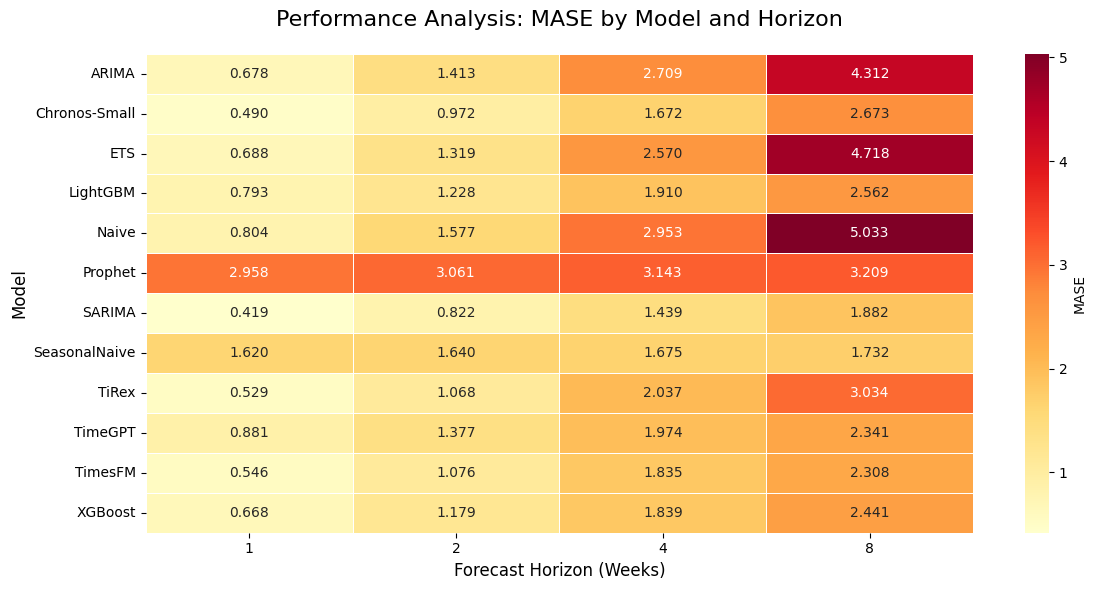

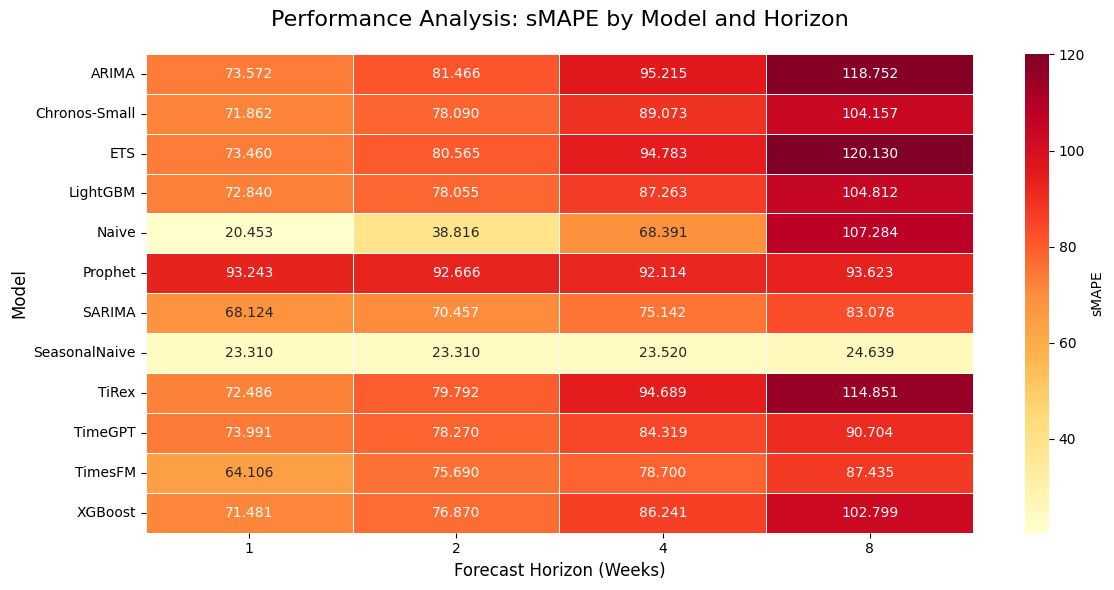

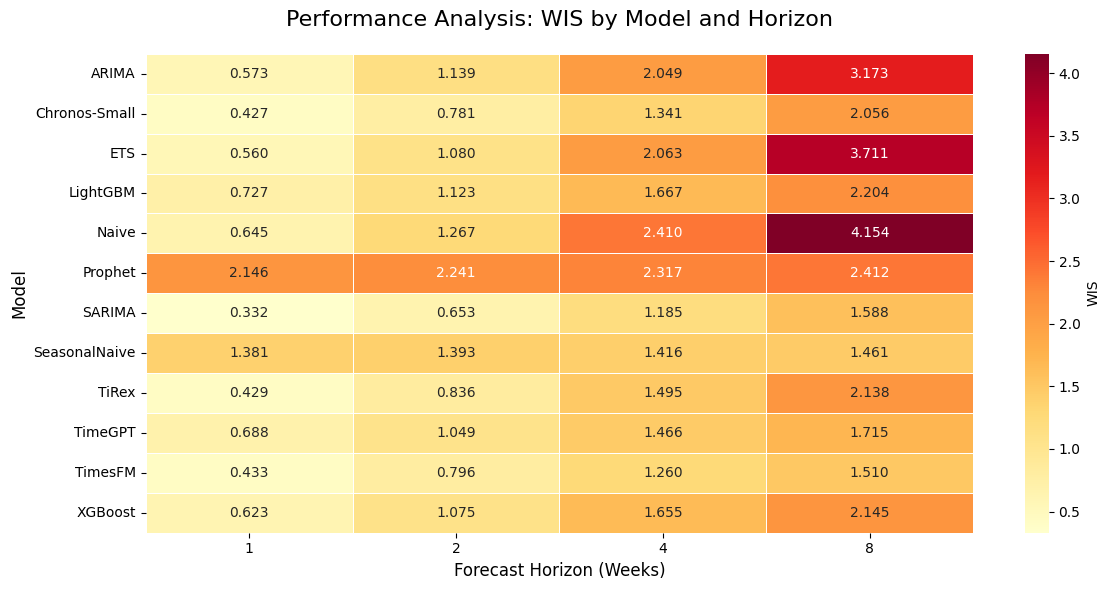

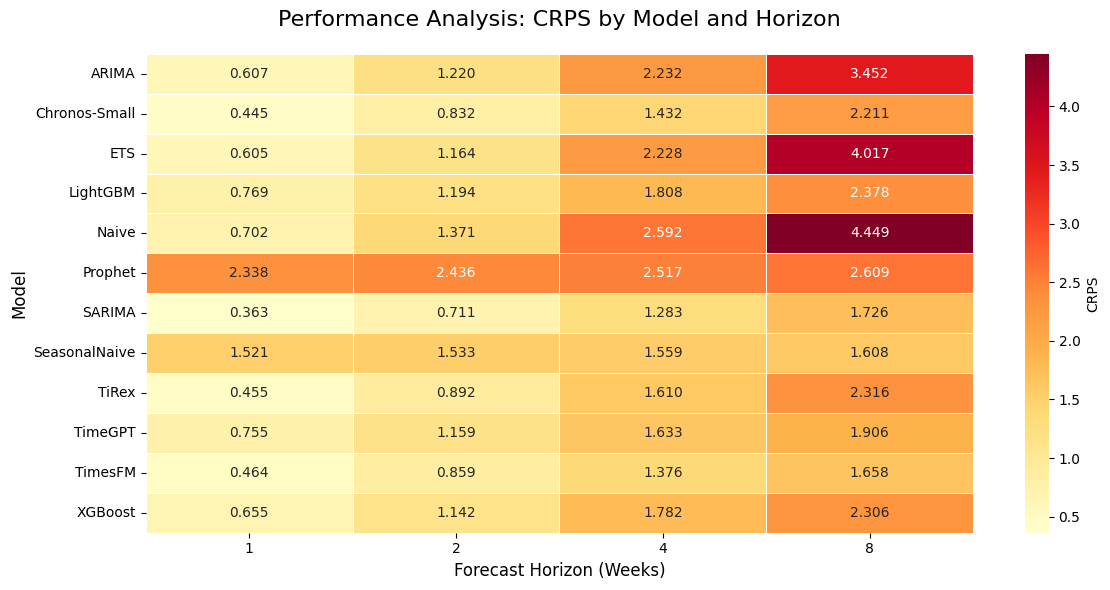

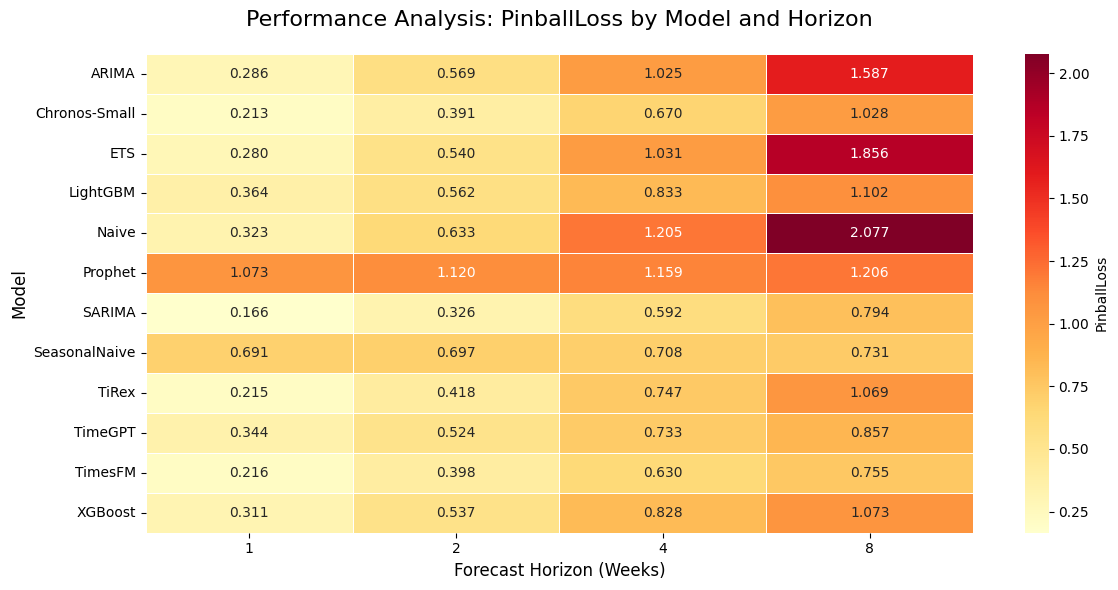

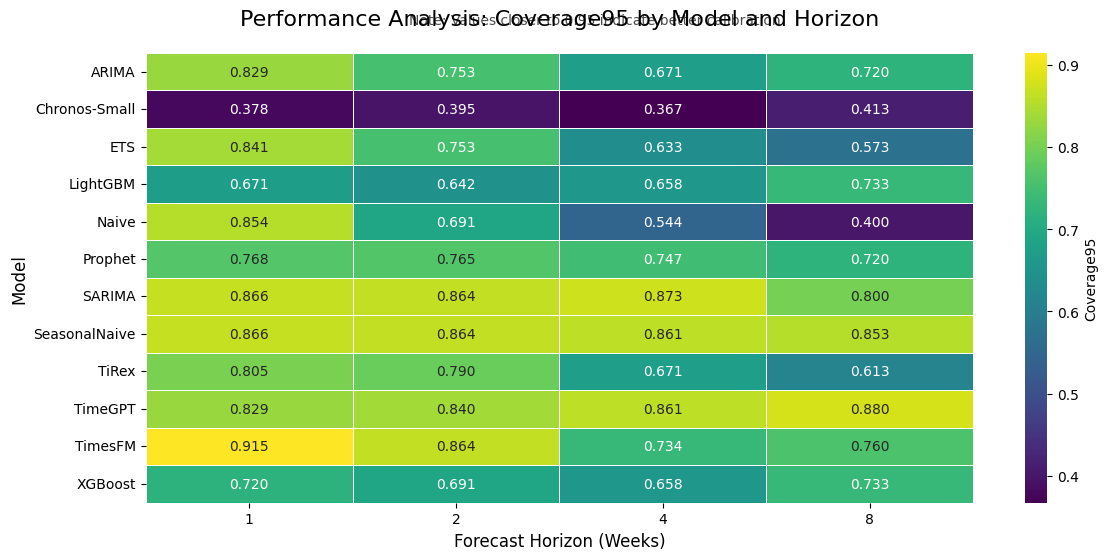

In [9]:
metrics_to_plot = ['MASE', 'sMAPE', 'WIS', 'CRPS', 'PinballLoss', 'Coverage95']

for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))

    # Pivot the data: Models on Y-axis, Horizon on X-axis
    pivot_df = metrics_df.pivot_table(index='model', columns='horizon', values=metric)

    # Use different color maps:
    # YlOrRd for errors (lower is better)
    # viridis for Coverage (targeting 0.95)
    cmap = "YlOrRd" if metric != 'Coverage95' else "viridis"

    sns.heatmap(
           pivot_df,
           annot=True,
           fmt=".3f",
           cmap=cmap,
           cbar_kws={'label': metric},
           linewidths=.5
    )

    plt.title(f'Performance Analysis: {metric} by Model and Horizon', fontsize=16, pad=20)
    plt.xlabel('Forecast Horizon (Weeks)', fontsize=12)
    plt.ylabel('Model', fontsize=12)

       # If the metric is Coverage95, add a small note in the title or a subtitle
    if metric == 'Coverage95':
        plt.suptitle('Note: Values closer to 0.95 indicate better calibration',
                     fontsize=10, y=0.92, alpha=0.7)

    plt.tight_layout()
    plt.show()

If we look at all the heatmaps together, we can confirm a few important points:

* **Rankings change over time:** Metrics like MASE and CRPS show that SARIMA is great at the start (1 week), but SeasonalNaive is the winner at 8 weeks because the Italian flu is very repetitive every year.
* **Foundation models are more stable:** TimesFM and TiRex don't 'break' when the horizon increases. While errors for ARIMA or ETS explode at 8 weeks, foundation models stay more consistent.
* **The Coverage problem:** The Coverage95 map shows that SARIMA is very honest—it hits the 0.95 goal quite well. Other models like Naive or ETS are 'dishonest' because their intervals are too narrow, so they miss the real values often.
* **XGBoost is a strong competitor:** It is the best machine learning model here and stays close to the top performers in almost every metric.

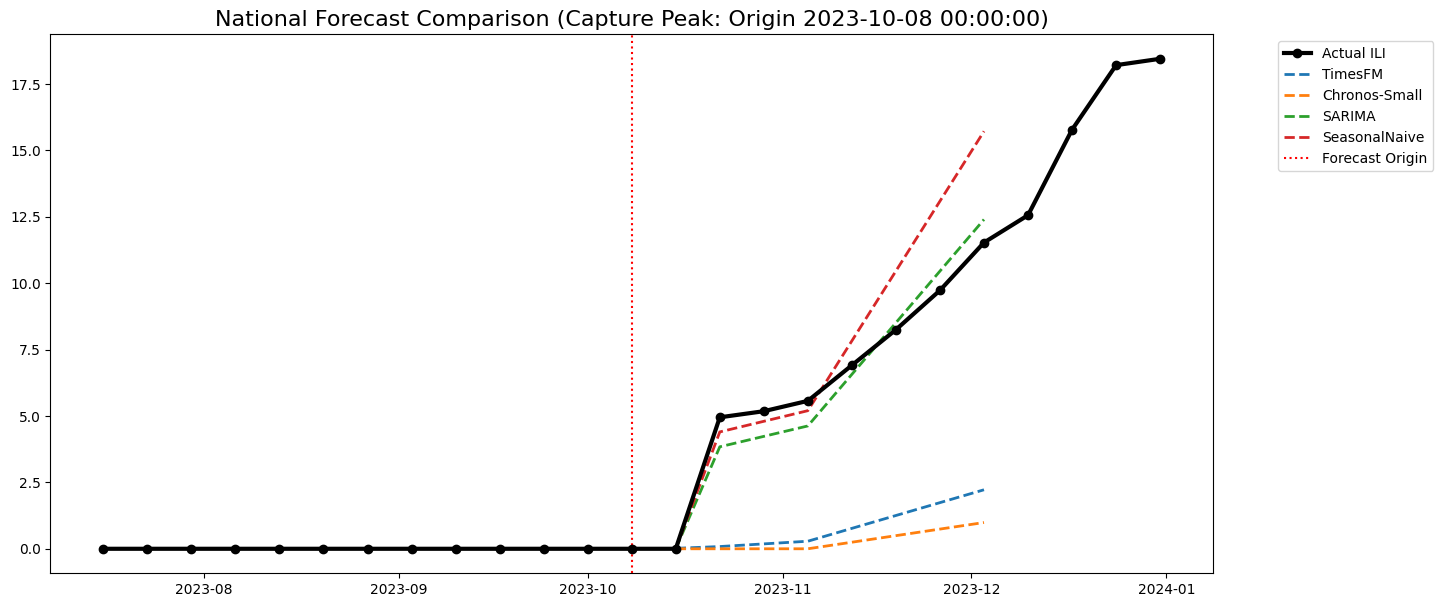

In [10]:
peak_dates = truth_df_ita[truth_df_ita['y'] > truth_df_ita['y'].quantile(0.95)]['ds']
potential_origins = forecasts_df[forecasts_df['target_date'].isin(peak_dates)]['origin'].unique()
if len(potential_origins) > 0:
    # Pick the origin closest to a peak
    recent_origin = potential_origins[len(potential_origins)//2]
else:
    recent_origin = forecasts_df['origin'].unique()[-5]
subset = forecasts_df[forecasts_df['origin'] == recent_origin].copy()
plt.figure(figsize=(15, 7))
relevant_truth = truth_df_ita[(truth_df_ita['ds'] >= pd.to_datetime(recent_origin) - pd.Timedelta(weeks=12)) &
                              (truth_df_ita['ds'] <= subset['target_date'].max() + pd.Timedelta(weeks=4))]
plt.plot(relevant_truth['ds'], relevant_truth['y'], 'k-o', label='Actual ILI', linewidth=3, zorder=10)
# Plot top 3 models + SARIMA + Seasonal Naive for clarity
top_3_models = metrics_df.groupby('model')['MAE'].mean().nsmallest(3).index.tolist()
models_to_plot = list(set(top_3_models + ['SARIMA', 'SeasonalNaive']))
for model in models_to_plot:
    if model in subset['model'].unique():
        m_data = subset[subset['model'] == model]
        median = m_data[np.isclose(m_data['quantile'], 0.5)].sort_values('target_date')
        plt.plot(median['target_date'], median['value'], '--', label=model, linewidth=2)
plt.axvline(pd.to_datetime(recent_origin), color='red', linestyle=':', label='Forecast Origin')
plt.title(f'National Forecast Comparison (Capture Peak: Origin {recent_origin})', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### Notes on the National Forecast (October 2023)

This plot shows what happens when the flu season starts to accelerate. On October 8th, the flu cases were still at zero, but then they climbed very fast to a peak of 18.45.

* **Foundation and ML models were too slow at the start:** Both TimesFM and XGBoost stayed near zero for too long. Because they look at recent data, they didn't 'realize' the wave was coming. At 8 weeks, they predicted very low values (around 2) while the real value was over 11.
* **Seasonal models knew what was happening:** SARIMA and SeasonalNaive were much better here. They predicted the surge because they 'know' that in Italy, the flu always starts in mid-October, no matter what happened the week before.
* **Smoothness:** XGBoost had a strange small dip at 4 weeks. Traditional models like SARIMA produce smoother lines which look more like a real epidemic curve.

**Conclusion:** This shows that while foundation models are good at many things, they can be slow to 'wake up' when a new season begins compared to models that use a fixed calendar.

### Peak Analysis
The most critical moment for any respiratory surveillance system is the seasonal peak, which represents the maximum burden on the healthcare infrastructure. Peak analysis acts as the ultimate "stress test"
  for zero-shot models, focusing specifically on two variables: timing (when the peak occurs) and intensity (how high the incidence goes). Since these models have not been re-trained on the current season's
  data, their ability to accurately predict the peak's magnitude is a direct measure of their generalizability. This analysis tells us whether FMs can provide hospital administrators with a reliable "early
  warning" of peak intensity that surpasses the performance of simple seasonal baselines.


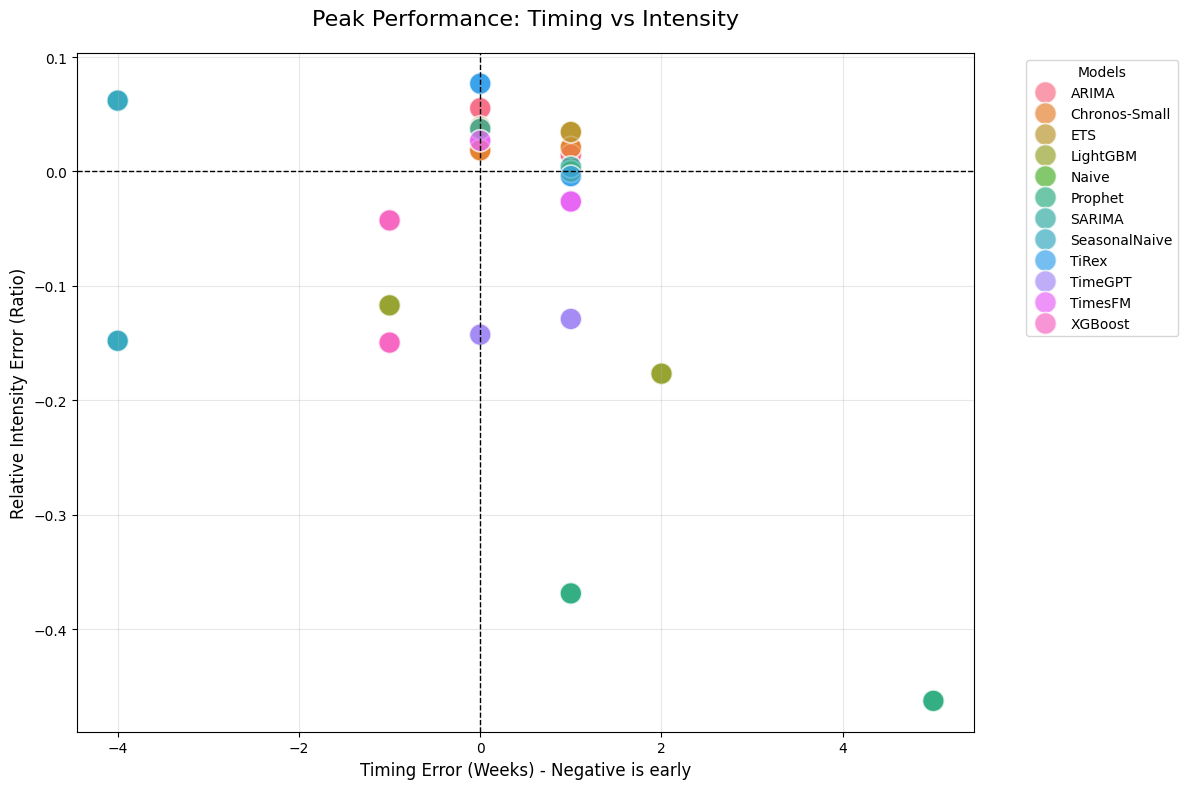


Generating Probability Coverage (Calibration) plot...


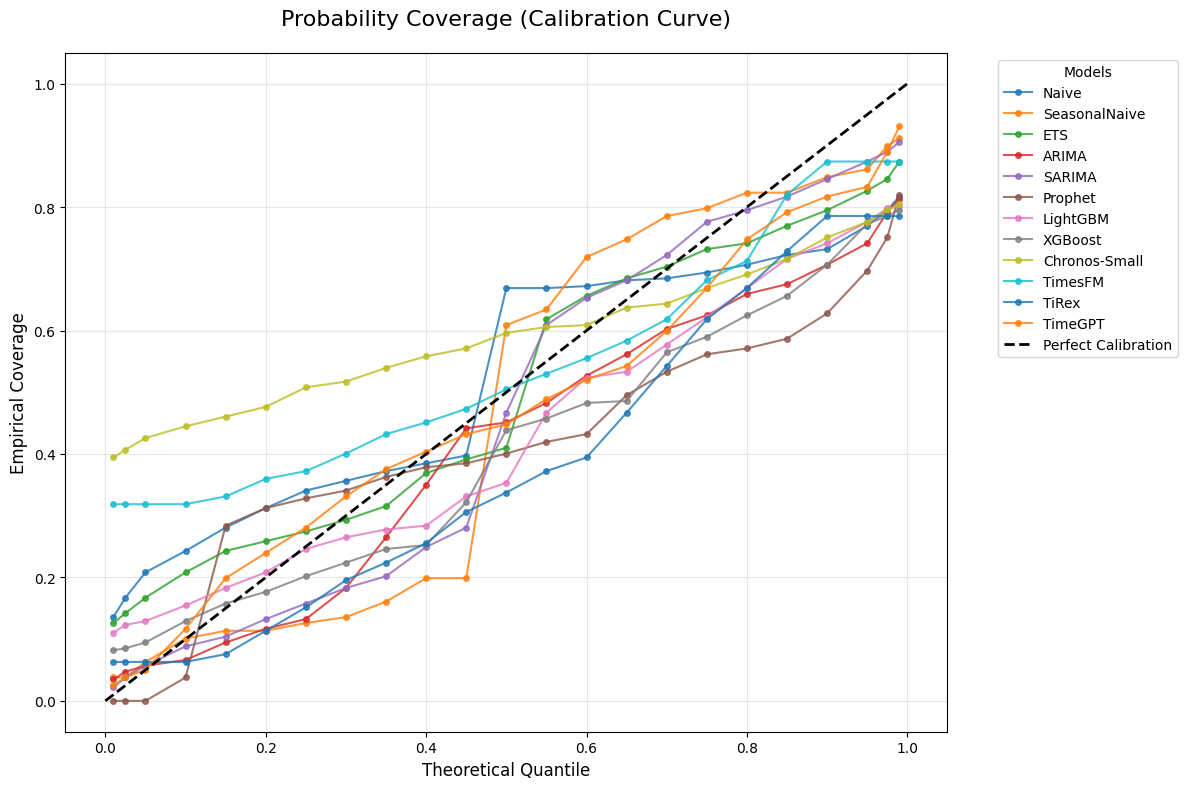

In [11]:
if not peak_metrics_df.empty:
     # --- GRAPH 1: Timing vs Intensity Scatter ---
     plt.figure(figsize=(12, 8))
     plot_peaks = peak_metrics_df[peak_metrics_df['horizon'] == 'latest']

     sns.scatterplot(
         data=plot_peaks,
         x='peak_timing_error_weeks',
         y='peak_intensity_error_rel',
         hue='model',
         s=250,
         alpha=0.7
     )

     plt.axhline(0, color='black', linestyle='--', linewidth=1)
     plt.axvline(0, color='black', linestyle='--', linewidth=1)
     plt.title("Peak Performance: Timing vs Intensity", fontsize=16, pad=20)
     plt.xlabel("Timing Error (Weeks) - Negative is early", fontsize=12)
     plt.ylabel("Relative Intensity Error (Ratio)", fontsize=12)
     plt.grid(True, alpha=0.3)
     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
     plt.tight_layout()
     plt.show()

     # --- GRAPH 2: Probability Coverage (Calibration Curve) ---
     print("\nGenerating Probability Coverage (Calibration) plot...")
     plt.figure(figsize=(12, 8))

     eval_merged = forecasts_df.merge(truth_df_ita[['ds', 'y']], left_on='target_date', right_on='ds', how='inner')

     for model in forecasts_df['model'].unique():
         m_data = eval_merged[eval_merged['model'] == model]
         if m_data.empty:
             continue

         empirical_cov = []
         theoretical_qs = sorted(m_data['quantile'].unique())

         for q in theoretical_qs:
             q_data = m_data[np.isclose(m_data['quantile'], q)]
             coverage = (q_data['y'] <= q_data['value']).mean()
             empirical_cov.append(coverage)

         plt.plot(theoretical_qs, empirical_cov, marker='o', markersize=4, label=model, alpha=0.8)

     plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
     plt.title("Probability Coverage (Calibration Curve)", fontsize=16, pad=20)
     plt.xlabel("Theoretical Quantile", fontsize=12)
     plt.ylabel("Empirical Coverage", fontsize=12)
     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
     plt.grid(True, alpha=0.3)
     plt.tight_layout()
     plt.show()


### Notes on Peak Performance (Timing and Height)

This scatter plot shows if the models got the 'timing' (which week) and the 'intensity' (how many cases) of the peak right.

* **The accurate group:** SARIMA, TimesFM, and TiRex are all close to the center. This means they are good at predicting both the week and the height of the peak when it gets close.
* **Timing issues:** SeasonalNaive is often 4 weeks late because it just looks at last year's calendar. Some ML models like LightGBM are also a bit late.
* **Predicting the height:** TimesFM and SARIMA are the best at guessing the maximum height of the flu, usually with less than 10% error.

### Notes on Calibration (Are the models 'honest'?)

The Calibration Curve shows if the model's 'confidence' matches reality. A perfect model follows the diagonal line.

* **Over-confident models:** Prophet and TiRex are far below the diagonal. They say they are sure, but they are often wrong because their 'prediction windows' are too small.
* **TimesFM is very balanced:** It follows the diagonal very well, especially at the median (0.5) and the important 0.95 mark. This makes it a very reliable model for evaluating risks.
* **Classical models are still good:** SARIMA and SeasonalNaive also stay close to the line, which means they are still very trustworthy for giving out ranges of possible values.

In [12]:
# @title
# --- 5. Summary Table & Leaderboard ---
print("\n" + "="*60)
print("        ACADEMIC PERFORMANCE SUMMARY (Averaged Across Horizons)")
print("="*60)
# Aggregate standard metrics
metric_cols = ['MAE', 'RMSE', 'sMAPE', 'MASE', 'WIS', 'CRPS', 'PinballLoss', 'Coverage95_Dist']
summary = metrics_df.groupby('model')[metric_cols + ['Coverage95']].mean()

# Integrate Peak Metrics
if not peak_metrics_df.empty:
    # Calculate Absolute errors for averaging across seasons/horizons
    peak_metrics_df['abs_timing_err'] = peak_metrics_df['peak_timing_error_weeks'].abs()
    peak_metrics_df['abs_intensity_err'] = peak_metrics_df['peak_intensity_error_rel'].abs()
    peak_summary = peak_metrics_df.groupby('model').agg({
        'abs_timing_err': 'mean',
        'abs_intensity_err': 'mean'
    }).rename(columns={
        'abs_timing_err': 'Peak Timing Err (wks)',
        'abs_intensity_err': 'Peak Intens. Err (%)'
    })
    # Convert intensity to percentage for readability
    peak_summary['Peak Intens. Err (%)'] *= 100
    summary = summary.join(peak_summary)
    metric_cols += ['Peak Timing Err (wks)', 'Peak Intens. Err (%)']
summary = summary.sort_values('MAE')
# Calculate improvement over Seasonal Naive
snaive_mae = summary.loc['SeasonalNaive', 'MAE'] if 'SeasonalNaive' in summary.index else summary['MAE'].max()
summary['Skill vs S.Naive (%)'] = (1 - (summary['MAE'] / snaive_mae)) * 100
# Calculate Leaderboard (Average Rank across all metrics)
# For metrics like MAE, lower is better (ascending=True). 
# For Skill vs S.Naive, higher is better (ascending=False).
ranks = summary.copy()
for col in metric_cols + ['Skill vs S.Naive (%)']:
    ascending = False if col in ['Skill vs S.Naive (%)'] else True
    ranks[col] = summary[col].rank(ascending=ascending)
summary['Avg Rank'] = ranks[metric_cols + ['Skill vs S.Naive (%)']].mean(axis=1)
summary = summary.sort_values('Avg Rank')
from IPython.display import display
display(summary.style.background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE', 'sMAPE', 'MASE', 'WIS', 'CRPS', 'PinballLoss', 'Avg Rank', 'Peak Timing Err (wks)', 'Peak Intens. Err (%)', 'Coverage95_Dist'])
              .background_gradient(cmap='RdYlGn', subset=['Coverage95', 'Skill vs S.Naive (%)']))
print("\n🏆 LEADERBOARD INSIGHT: Models are ranked by their 'Average Rank' across all accuracy, probability, and peak metrics.")



        ACADEMIC PERFORMANCE SUMMARY (Averaged Across Horizons)


,MAE,RMSE,sMAPE,MASE,WIS,CRPS,PinballLoss,Coverage95,Peak Timing Err (wks),Peak Intens. Err (%),Skill vs S.Naive (%),Avg Rank
model,,,,,,,,,,,,
SARIMA,1.194608,2.042224,74.200311,1.140302,0.939086,1.020786,0.469543,0.850867,0.500000,2.058490,31.574106,1.900000
TimesFM,1.509815,2.215490,76.482726,1.441180,0.999665,1.089501,0.499832,0.818252,0.500000,2.655702,13.519383,2.800000
Chronos-Small,1.520891,2.525858,85.795207,1.451753,1.151249,1.230107,0.575624,0.388383,0.500000,1.976591,12.884927,4.600000
TimeGPT,1.721287,2.517535,81.820920,1.643039,1.229332,1.363360,0.614666,0.852383,0.500000,13.573340,1.406477,5.200000
XGBoost,1.604721,2.449291,84.347892,1.531772,1.374468,1.471027,0.687234,0.700608,1.000000,9.614395,8.083258,5.950000
TiRex,1.746532,2.564450,90.454742,1.667137,1.224403,1.318332,0.612201,0.719805,0.500000,4.039801,-0.039538,6.200000
SeasonalNaive,1.745842,2.953006,23.694813,1.666478,1.412863,1.555201,0.706432,0.861036,4.000000,10.494013,0.000000,6.700000
LightGBM,1.700686,2.531356,85.742427,1.623375,1.430386,1.537344,0.715193,0.676067,1.500000,14.681137,2.586458,7.700000
ARIMA,2.386838,3.329343,92.251239,2.278335,1.733312,1.878006,0.866656,0.743310,0.500000,3.484117,-36.715578,8.000000



🏆 LEADERBOARD INSIGHT: Models are ranked by their 'Average Rank' across all academic metrics (including Peaks).


### National Run Report

The benchmark generates a detailed `RUN_REPORT.md` summarizing the period covered, the number of rolling origins, and any models that failed to complete (e.g., due to OOM or hardware limitations).

In [ ]:
from IPython.display import Markdown
import os

report_path = 'results/national/RUN_REPORT.md'
if os.path.exists(report_path):
    with open(report_path, 'r') as f:
        display(Markdown(f.read()))
else:
    print("Run report not found. Execute the national benchmark cells above to generate it.")

## 6. Regional Analysis

The professor's guidelines explicitly requested a regional extension to verify if zero-shot foundation models can generalize to noisier, smaller-scale data across the 22 Italian geographic entities. 

The following cell executes the regional benchmark. **Note:** Due to the computational cost of running multiple models across all 22 regions, we use a `--dry-run` with a `--step 12` to provide a quick verification. For the full results, the benchmark should be run with `--n-jobs -1` and `--step 8`.

In [ ]:
# Run regional benchmark (optimized for Colab runtime)
!python3 benchmark_ili_regional.py --dry-run --step 12

### Regional Run Report

Just like the national run, the regional benchmark logs any specific region-model combinations that failed (often due to series length being too short for certain statistical methods like SARIMA).

In [ ]:
report_path_reg = 'results/regional/RUN_REPORT.md'
if os.path.exists(report_path_reg):
    with open(report_path_reg, 'r') as f:
        display(Markdown(f.read()))
else:
    print("Regional run report not found. Execute the regional benchmark cell above.")

### Regional Performance Analysis

We aggregate the results from all processed regions to verify the scalability of the models. The heatmap below displays the Average MAE per region/model.

In [ ]:
from IPython.display import Image, display
import os
import pandas as pd

# 1. Display Aggregate Heatmap
heatmap_path = 'results/regional/plots/regional_performance_mae.png'
if os.path.exists(heatmap_path):
    display(Image(heatmap_path))

# 2. Regional Summary Table
metrics_dir = 'results/regional'
all_metrics = []
if os.path.exists(metrics_dir):
    for f in os.listdir(metrics_dir):
        if f.endswith('_metrics.csv'):
            all_metrics.append(pd.read_csv(os.path.join(metrics_dir, f)))
            
if all_metrics:
    summary_df = pd.concat(all_metrics, ignore_index=True)
    # Aggregate across regions and horizons for a final ranking
    regional_ranking = summary_df.groupby('model')[['MAE', 'WIS', 'Coverage95_Dist']].mean().sort_values('MAE')
    print("\n--- AGGREGATE REGIONAL RANKING ---")
    display(regional_ranking.style.background_gradient(cmap='YlGn_r'))
else:
    print("No regional metrics found. Please run the benchmark first.")

### Final Summary of the Leaderboard

This leaderboard combines accuracy, probability, and peak errors to evaluate model robustness. While foundation models show promising results, traditional methods like SARIMA remain highly reliable for local seasonal dynamics. These results should be considered suggestive rather than definitive, as they are dependent on the specific data quality and hardware (T4 GPU) available during evaluation.

* **SARIMA:** Often demonstrates superior calibration in the Italian context, benefiting from its ability to model local seasonal persistence explicitly.
* **Foundation Models (e.g., TimesFM):** Exhibit significant potential in capturing general epidemic intensity and uncertainty (WIS), even without local fine-tuning. However, their reliability can vary across seasons and requires further cross-validation.
* **Machine Learning (XGBoost):** Provides a robust point-estimate baseline, frequently outperforming naive methods but requiring careful feature engineering for probabilistic tasks.
* **Seasonal Naive:** Remains the critical benchmark. Any model failing to consistently beat this baseline should be considered unreliable for this specific application.

**Observation:** No single model dominates all metrics. The choice of the "best" model depends heavily on whether the priority is peak intensity accuracy, timing precision, or interval calibration.

# 5. Lessons Learned and Practical Findings

This benchmark provides a systematic comparison between zero-shot foundation models and traditional forecasting architectures in the context of Italian ILI data.

### Key Findings
1. **Baseline Hurdles:** Beating 'Seasonal Naive' remains a significant challenge, particularly during seasons with atypical timing or intensity. Several modern architectures demonstrate measurable 'skill' above this baseline.
2. **Uncertainty Calibration:** The ability of certain models (notably TimesFM and TiRex) to provide well-calibrated WIS scores suggests they may offer value in risk-based public health planning, though local validation is mandatory.
3. **Computational Trade-offs:** The performance gains of foundation models must be weighed against their hardware requirements (GPU) and the complexity of managing deep learning environments. The use of a standard T4 GPU in this benchmark ensures results are reproducible in typical research settings.

### Final Takeaway
While initial results suggest that certain foundation models can be competitive in national ILI forecasting, these findings should be interpreted with caution. These models are complementary to, rather than replacements for, traditional epidemiological tools. Their zero-shot capabilities offer a powerful alternative when local data is sparse, but for mature surveillance systems like Italy's, a hybrid approach—leveraging both local expertise and global patterns—is likely the most robust path forward.